In [1]:
import requests
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import timedelta, datetime
from math import radians, sin, cos, sqrt, atan2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

def haversine_nm(lat1, lon1, lat2, lon2):
    R = 3440.065
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

def add_relative_direction_features(df):
    df['relative_wave_direction'] = (df['wave_direction'] - df['course']) % 360
    df['relative_wind_wave_direction'] = (df['wind_wave_direction'] - df['course']) % 360
    df['relative_swell_wave_direction'] = (df['swell_wave_direction'] - df['course']) % 360
    df['relative_wind_direction_10m'] = (df['wind_direction_10m'] - df['course'] + 360) % 360
    df['relative_ocean_current_direction'] = (df['ocean_current_direction'] - df['course'] + 360) % 360

    rel_angle_rad_wind_wave = np.deg2rad(df['relative_wind_wave_direction'])
    rel_angle_rad_swell_wave = np.deg2rad(df['relative_swell_wave_direction'])
    rel_angle_rad_current = np.deg2rad(df['relative_ocean_current_direction'])

    df['wind_wave_effect_forward'] = df['wind_wave_height'] * np.cos(rel_angle_rad_wind_wave)
    df['wind_wave_effect_side'] = df['wind_wave_height'] * np.sin(rel_angle_rad_wind_wave)

    df['swell_effect_forward'] = df['swell_wave_height'] * np.cos(rel_angle_rad_swell_wave)
    df['swell_effect_side'] = df['swell_wave_height'] * np.sin(rel_angle_rad_swell_wave)

    df['ocean_current_effect_forward'] = df['ocean_current_velocity'] * np.cos(rel_angle_rad_current)
    df['ocean_current_effect_side'] = df['ocean_current_velocity'] * np.sin(rel_angle_rad_current)

    df.drop(columns=['wave_direction', 'relative_wave_direction',
                     'wind_wave_direction', 'relative_wind_wave_direction',
                     'swell_wave_direction', 'relative_swell_wave_direction',
                     'wind_direction_10m', 'relative_wind_direction_10m',
                     'ocean_current_direction', 'relative_ocean_current_direction'], inplace=True)
    
    return df

/Users/itsgil/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
weather_df = pd.read_pickle("full_weather.pkl")
weather_df['date'] = pd.to_datetime(weather_df['date'])
weather_df

vessel_info = pd.read_csv("vessel_info.csv")

# Merge vessel info
weather_df = weather_df.merge(
    vessel_info[['mmsi', 'speed_max']],
    on='mmsi',
    how='left'
)

In [ ]:
# For each entry with destination, destination_lat, and destination_lon NOTNULL,
# Calculate time left to reach the destination (until the next entry with destination null).
# Skip rows with destination null for calculation.

eta_rows = []
for journey_id, group in weather_df.groupby('journey_id'):
    group = group.sort_values('date').reset_index(drop=True)
    i = 0
    while i < len(group):
        row = group.iloc[i]
        # Only process if destination, lat, lon are not null
        if pd.notnull(row['destination']) and pd.notnull(row['destination_lat']) and pd.notnull(row['destination_lon']):
            # Find the next entry with destination null (same journey)
            j = i + 1
            while j < len(group):
                next_row = group.iloc[j]
                if pd.isnull(next_row['destination']):
                    break
                j += 1
            # If found, calculate time left for all entries from i up to j-1
            if j < len(group):
                arrival_time = group.iloc[j]['date']
                for k in range(i, j):
                    entry = group.iloc[k].copy()
                    entry['time_left_to_destination'] = (arrival_time - entry['date']).total_seconds() / 3600.0  # hours
                    eta_rows.append(entry)
                i = j + 1  # Skip the null destination row
            else:
                # If no null destination found, skip to next journey or end
                break
        else:
            i += 1

eta_df = pd.DataFrame(eta_rows)
eta_df

,journey_id,shipid,lat,lon,speed_kn,course,date,source,nav_status,draught,...,wind_wave_period,swell_wave_height,swell_wave_direction,swell_wave_period,ocean_current_velocity,ocean_current_direction,wind_speed_10m,wind_direction_10m,speed_max,time_left_to_destination
73,1,731863,53.578335,8.552292,0.0,26.0,2022-03-15 13:40:00,Terrestrial,0,8.6,...,1.0,0.08,298.0,2.9,0.0,90.0,6.2,201.0,20.0,42.749167
74,1,731863,53.578335,8.552292,0.0,40.0,2022-03-15 13:43:02,Terrestrial,0,8.6,...,1.0,0.08,298.0,2.9,0.0,90.0,6.2,201.0,20.0,42.698611
75,1,731863,53.578259,8.552069,0.6,222.0,2022-03-15 13:59:04,Terrestrial,0,8.6,...,1.0,0.08,298.0,2.9,0.0,90.0,6.2,201.0,20.0,42.431389
76,1,731863,53.577595,8.551690,1.3,189.0,2022-03-15 14:01:33,Terrestrial,0,8.6,...,1.0,0.08,298.0,2.9,0.0,90.0,6.2,201.0,20.0,42.390000
77,1,731863,53.574875,8.550992,1.5,216.0,2022-03-15 14:08:05,Terrestrial,0,8.6,...,1.0,0.08,298.0,2.9,0.0,90.0,6.2,201.0,20.0,42.281111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070,396,4189877,40.663692,-74.066093,4.8,310.0,2023-10-08 23:23:35,Terrestrial,0,9.6,...,2.2,0.26,117.0,9.3,0.4,63.0,15.4,249.0,20.0,0.690278
1071,396,4189877,40.665329,-74.068558,3.3,308.0,2023-10-08 23:25:46,Terrestrial,0,9.6,...,2.2,0.26,117.0,9.3,0.4,63.0,15.4,249.0,20.0,0.653889
1072,396,4189877,40.666634,-74.070503,0.9,305.0,2023-10-08 23:29:35,Terrestrial,0,9.6,...,2.2,0.26,117.0,9.3,0.4,63.0,15.4,249.0,20.0,0.590278
1073,396,4189877,40.666859,-74.070717,0.1,338.0,2023-10-08 23:31:56,Terrestrial,0,9.6,...,2.3,0.50,104.0,9.8,0.3,45.0,15.4,249.0,20.0,0.551111


In [4]:
eta_df = add_relative_direction_features(eta_df)

eta_df['swell_impact'] = eta_df['swell_wave_height'] ** 2 * eta_df['swell_wave_period']
eta_df['wind_wave_energy'] = eta_df['wind_wave_height'] ** 2 * eta_df['wind_wave_period']

eta_df.drop(columns=['wave_height', 'wind_wave_height', 'swell_wave_height',
                     'wind_speed_10m','ocean_current_velocity',
                     'wave_period', 'swell_wave_period', 'wind_wave_period'], inplace=True)

eta_df

,journey_id,shipid,lat,lon,speed_kn,course,date,source,nav_status,draught,...,speed_max,time_left_to_destination,wind_wave_effect_forward,wind_wave_effect_side,swell_effect_forward,swell_effect_side,ocean_current_effect_forward,ocean_current_effect_side,swell_impact,wind_wave_energy
73,1,731863,53.578335,8.552292,0.0,26.0,2022-03-15 13:40:00,Terrestrial,0,8.6,...,20.0,42.749167,-0.003816,0.019633,0.002792,-0.079951,0.000000,0.000000,0.01856,0.00040
74,1,731863,53.578335,8.552292,0.0,40.0,2022-03-15 13:43:02,Terrestrial,0,8.6,...,20.0,42.698611,0.001047,0.019973,-0.016633,-0.078252,0.000000,0.000000,0.01856,0.00040
75,1,731863,53.578259,8.552069,0.6,222.0,2022-03-15 13:59:04,Terrestrial,0,8.6,...,20.0,42.431389,-0.001743,-0.019924,0.019354,0.077624,-0.000000,-0.000000,0.01856,0.00040
76,1,731863,53.577595,8.551690,1.3,189.0,2022-03-15 14:01:33,Terrestrial,0,8.6,...,20.0,42.390000,0.009389,-0.017659,-0.026045,0.075641,-0.000000,-0.000000,0.01856,0.00040
77,1,731863,53.574875,8.550992,1.5,216.0,2022-03-15 14:08:05,Terrestrial,0,8.6,...,20.0,42.281111,0.000349,-0.019997,0.011134,0.079221,-0.000000,-0.000000,0.01856,0.00040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070,396,4189877,40.663692,-74.066093,4.8,310.0,2023-10-08 23:23:35,Terrestrial,0,9.6,...,20.0,0.690278,0.192581,-0.255563,-0.253336,0.058487,-0.156292,0.368202,0.62868,0.22528
1071,396,4189877,40.665329,-74.068558,3.3,308.0,2023-10-08 23:25:46,Terrestrial,0,9.6,...,20.0,0.653889,0.201383,-0.248687,-0.255223,0.049610,-0.169047,0.362523,0.62868,0.22528
1072,396,4189877,40.666634,-74.070503,0.9,305.0,2023-10-08 23:29:35,Terrestrial,0,9.6,...,20.0,0.590278,0.214122,-0.237806,-0.257470,0.036185,-0.187789,0.353179,0.62868,0.22528
1073,396,4189877,40.666859,-74.070717,0.1,338.0,2023-10-08 23:31:56,Terrestrial,0,9.6,...,20.0,0.551111,0.099229,-0.346054,-0.293893,0.404508,0.117219,0.276151,2.45000,0.29808


In [ ]:
# Delete irrelevant columns
eta_df = eta_df.drop(columns=['journey_id',
                              'shipid', 'destination',
                              'speed_kn', 'course',
                              'source', 'nav_status',
                              'draught', 'mmsi',
                              ])

# Drop rows with any nulls in a column
eta_df = eta_df.dropna()
eta_df.to_csv("eta_model_data.csv", index=False)
eta_df

,lat,lon,date,destination_lat,destination_lon,speed_max,time_left_to_destination,wind_wave_effect_forward,wind_wave_effect_side,swell_effect_forward,swell_effect_side,ocean_current_effect_forward,ocean_current_effect_side,swell_impact,wind_wave_energy
73,53.578335,8.552292,2022-03-15 13:40:00,50.89817,-1.420503,20.0,42.749167,-0.003816,0.019633,0.002792,-0.079951,0.000000,0.000000,0.01856,0.00040
74,53.578335,8.552292,2022-03-15 13:43:02,50.89817,-1.420503,20.0,42.698611,0.001047,0.019973,-0.016633,-0.078252,0.000000,0.000000,0.01856,0.00040
75,53.578259,8.552069,2022-03-15 13:59:04,50.89817,-1.420503,20.0,42.431389,-0.001743,-0.019924,0.019354,0.077624,-0.000000,-0.000000,0.01856,0.00040
76,53.577595,8.551690,2022-03-15 14:01:33,50.89817,-1.420503,20.0,42.390000,0.009389,-0.017659,-0.026045,0.075641,-0.000000,-0.000000,0.01856,0.00040
77,53.574875,8.550992,2022-03-15 14:08:05,50.89817,-1.420503,20.0,42.281111,0.000349,-0.019997,0.011134,0.079221,-0.000000,-0.000000,0.01856,0.00040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070,40.663692,-74.066093,2023-10-08 23:23:35,40.68400,-74.155000,20.0,0.690278,0.192581,-0.255563,-0.253336,0.058487,-0.156292,0.368202,0.62868,0.22528
1071,40.665329,-74.068558,2023-10-08 23:25:46,40.68400,-74.155000,20.0,0.653889,0.201383,-0.248687,-0.255223,0.049610,-0.169047,0.362523,0.62868,0.22528
1072,40.666634,-74.070503,2023-10-08 23:29:35,40.68400,-74.155000,20.0,0.590278,0.214122,-0.237806,-0.257470,0.036185,-0.187789,0.353179,0.62868,0.22528
1073,40.666859,-74.070717,2023-10-08 23:31:56,40.68400,-74.155000,20.0,0.551111,0.099229,-0.346054,-0.293893,0.404508,0.117219,0.276151,2.45000,0.29808


In [6]:
hurdat_df = pd.read_pickle("hurdat2_storm_data_2020_2025.pkl")
hurdat_df['storm_timestamp'] = pd.to_datetime(hurdat_df['datetime'])
hurdat_df

,storm_id,storm_name,system_status,lat,lon,max_sustained_wind,datetime,system_status_desc,storm_timestamp
0,AL012020,ARTHUR,TD,28.0,-78.7,30,2020-05-16 18:00:00,Tropical Depression (<34 knots),2020-05-16 18:00:00
1,AL012020,ARTHUR,TS,28.9,-78.0,35,2020-05-17 00:00:00,Tropical Storm (34-63 knots),2020-05-17 00:00:00
2,AL012020,ARTHUR,TS,29.6,-77.6,35,2020-05-17 06:00:00,Tropical Storm (34-63 knots),2020-05-17 06:00:00
3,AL012020,ARTHUR,TS,30.3,-77.5,35,2020-05-17 12:00:00,Tropical Storm (34-63 knots),2020-05-17 12:00:00
4,AL012020,ARTHUR,TS,31.0,-77.3,40,2020-05-17 18:00:00,Tropical Storm (34-63 knots),2020-05-17 18:00:00
...,...,...,...,...,...,...,...,...,...
3302,AL052025,ERIN,TS,17.5,-33.3,40,2025-08-12 06:00:00,Tropical Storm (34-63 knots),2025-08-12 06:00:00
3303,AL052025,ERIN,TS,17.3,-35.4,40,2025-08-12 12:00:00,Tropical Storm (34-63 knots),2025-08-12 12:00:00
3304,AL052025,ERIN,TS,17.1,-37.4,40,2025-08-12 18:00:00,Tropical Storm (34-63 knots),2025-08-12 18:00:00
3305,AL052025,ERIN,TS,16.8,-39.3,40,2025-08-13 00:00:00,Tropical Storm (34-63 knots),2025-08-13 00:00:00


In [7]:
# Parameters for storm proximity
D = 800  # nautical miles (logical: storms can affect ships within ~800nm)
DELTA_HOURS = 48  # hours before/after (logical: storm impact window)

affected_by_storm = []
for idx, row in tqdm(eta_df.iterrows(), total=eta_df.shape[0], desc="Marking storm-affected entries"):
    lat, lon, date = row['lat'], row['lon'], pd.to_datetime(row['date'])
    # Filter storms within DELTA_HOURS of entry date
    storms_time = hurdat_df[
        (hurdat_df['storm_timestamp'] >= date - pd.Timedelta(hours=DELTA_HOURS)) &
        (hurdat_df['storm_timestamp'] <= date + pd.Timedelta(hours=DELTA_HOURS))
    ]
    # Calculate distance to each storm
    storms_time = storms_time.copy()
    storms_time['distance_nm'] = storms_time.apply(
        lambda x: haversine_nm(lat, lon, x['lat'], x['lon']), axis=1
    )
    # Mark as affected if any storm is within D nautical miles
    affected = not storms_time[storms_time['distance_nm'] <= D].empty
    affected_by_storm.append(affected)

eta_df['affected_by_storm'] = affected_by_storm
eta_df.to_csv('marked_affected_storms.csv', index=False)
eta_df

Marking storm-affected entries: 100%|██████████| 239200/239200 [01:57<00:00, 2038.55it/s]



,lat,lon,date,destination_lat,destination_lon,speed_max,time_left_to_destination,wind_wave_effect_forward,wind_wave_effect_side,swell_effect_forward,swell_effect_side,ocean_current_effect_forward,ocean_current_effect_side,swell_impact,wind_wave_energy,affected_by_storm
73,53.578335,8.552292,2022-03-15 13:40:00,50.89817,-1.420503,20.0,42.749167,-0.003816,0.019633,0.002792,-0.079951,0.000000,0.000000,0.01856,0.00040,False
74,53.578335,8.552292,2022-03-15 13:43:02,50.89817,-1.420503,20.0,42.698611,0.001047,0.019973,-0.016633,-0.078252,0.000000,0.000000,0.01856,0.00040,False
75,53.578259,8.552069,2022-03-15 13:59:04,50.89817,-1.420503,20.0,42.431389,-0.001743,-0.019924,0.019354,0.077624,-0.000000,-0.000000,0.01856,0.00040,False
76,53.577595,8.551690,2022-03-15 14:01:33,50.89817,-1.420503,20.0,42.390000,0.009389,-0.017659,-0.026045,0.075641,-0.000000,-0.000000,0.01856,0.00040,False
77,53.574875,8.550992,2022-03-15 14:08:05,50.89817,-1.420503,20.0,42.281111,0.000349,-0.019997,0.011134,0.079221,-0.000000,-0.000000,0.01856,0.00040,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070,40.663692,-74.066093,2023-10-08 23:23:35,40.68400,-74.155000,20.0,0.690278,0.192581,-0.255563,-0.253336,0.058487,-0.156292,0.368202,0.62868,0.22528,False
1071,40.665329,-74.068558,2023-10-08 23:25:46,40.68400,-74.155000,20.0,0.653889,0.201383,-0.248687,-0.255223,0.049610,-0.169047,0.362523,0.62868,0.22528,False
1072,40.666634,-74.070503,2023-10-08 23:29:35,40.68400,-74.155000,20.0,0.590278,0.214122,-0.237806,-0.257470,0.036185,-0.187789,0.353179,0.62868,0.22528,False
1073,40.666859,-74.070717,2023-10-08 23:31:56,40.68400,-74.155000,20.0,0.551111,0.099229,-0.346054,-0.293893,0.404508,0.117219,0.276151,2.45000,0.29808,False


In [8]:
# Filter out rows affected by storms
eta_df = eta_df[~eta_df['affected_by_storm']]
eta_df

,lat,lon,date,destination_lat,destination_lon,speed_max,time_left_to_destination,wind_wave_effect_forward,wind_wave_effect_side,swell_effect_forward,swell_effect_side,ocean_current_effect_forward,ocean_current_effect_side,swell_impact,wind_wave_energy,affected_by_storm
73,53.578335,8.552292,2022-03-15 13:40:00,50.89817,-1.420503,20.0,42.749167,-0.003816,0.019633,0.002792,-0.079951,0.000000,0.000000,0.01856,0.00040,False
74,53.578335,8.552292,2022-03-15 13:43:02,50.89817,-1.420503,20.0,42.698611,0.001047,0.019973,-0.016633,-0.078252,0.000000,0.000000,0.01856,0.00040,False
75,53.578259,8.552069,2022-03-15 13:59:04,50.89817,-1.420503,20.0,42.431389,-0.001743,-0.019924,0.019354,0.077624,-0.000000,-0.000000,0.01856,0.00040,False
76,53.577595,8.551690,2022-03-15 14:01:33,50.89817,-1.420503,20.0,42.390000,0.009389,-0.017659,-0.026045,0.075641,-0.000000,-0.000000,0.01856,0.00040,False
77,53.574875,8.550992,2022-03-15 14:08:05,50.89817,-1.420503,20.0,42.281111,0.000349,-0.019997,0.011134,0.079221,-0.000000,-0.000000,0.01856,0.00040,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070,40.663692,-74.066093,2023-10-08 23:23:35,40.68400,-74.155000,20.0,0.690278,0.192581,-0.255563,-0.253336,0.058487,-0.156292,0.368202,0.62868,0.22528,False
1071,40.665329,-74.068558,2023-10-08 23:25:46,40.68400,-74.155000,20.0,0.653889,0.201383,-0.248687,-0.255223,0.049610,-0.169047,0.362523,0.62868,0.22528,False
1072,40.666634,-74.070503,2023-10-08 23:29:35,40.68400,-74.155000,20.0,0.590278,0.214122,-0.237806,-0.257470,0.036185,-0.187789,0.353179,0.62868,0.22528,False
1073,40.666859,-74.070717,2023-10-08 23:31:56,40.68400,-74.155000,20.0,0.551111,0.099229,-0.346054,-0.293893,0.404508,0.117219,0.276151,2.45000,0.29808,False


In [9]:
eta_df['distance_to_destination_nm'] = eta_df.apply(
    lambda row: haversine_nm(row['lat'], row['lon'], row['destination_lat'], row['destination_lon']),
    axis=1
)
eta_df.drop(columns=['lat', 'lon', 'destination_lat', 'destination_lon', 'date', 'affected_by_storm'], inplace=True)
eta_df.to_csv("eta_model_data_filtered.csv", index=False)
eta_df

/var/folders/ff/dr79vq4s3c947t14rk9tly8r0000gn/T/ipykernel_17746/2650979769.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eta_df['distance_to_destination_nm'] = eta_df.apply(
/var/folders/ff/dr79vq4s3c947t14rk9tly8r0000gn/T/ipykernel_17746/2650979769.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eta_df.drop(columns=['lat', 'lon', 'destination_lat', 'destination_lon', 'date', 'affected_by_storm'], inplace=True)


,speed_max,time_left_to_destination,wind_wave_effect_forward,wind_wave_effect_side,swell_effect_forward,swell_effect_side,ocean_current_effect_forward,ocean_current_effect_side,swell_impact,wind_wave_energy,distance_to_destination_nm
73,20.0,42.749167,-0.003816,0.019633,0.002792,-0.079951,0.000000,0.000000,0.01856,0.00040,399.982633
74,20.0,42.698611,0.001047,0.019973,-0.016633,-0.078252,0.000000,0.000000,0.01856,0.00040,399.982633
75,20.0,42.431389,-0.001743,-0.019924,0.019354,0.077624,-0.000000,-0.000000,0.01856,0.00040,399.973604
76,20.0,42.390000,0.009389,-0.017659,-0.026045,0.075641,-0.000000,-0.000000,0.01856,0.00040,399.947464
77,20.0,42.281111,0.000349,-0.019997,0.011134,0.079221,-0.000000,-0.000000,0.01856,0.00040,399.869039
...,...,...,...,...,...,...,...,...,...,...,...
1070,20.0,0.690278,0.192581,-0.255563,-0.253336,0.058487,-0.156292,0.368202,0.62868,0.22528,4.228147
1071,20.0,0.653889,0.201383,-0.248687,-0.255223,0.049610,-0.169047,0.362523,0.62868,0.22528,4.092744
1072,20.0,0.590278,0.214122,-0.237806,-0.257470,0.036185,-0.187789,0.353179,0.62868,0.22528,3.986394
1073,20.0,0.551111,0.099229,-0.346054,-0.293893,0.404508,0.117219,0.276151,2.45000,0.29808,3.973462


In [10]:
eta_df = pd.read_csv("eta_model_data_filtered.csv")

y = eta_df["time_left_to_destination"].values
X = eta_df.drop(columns=["time_left_to_destination"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

exclude_cols = ['time_left_to_destination']
scale_cols = [col for col in X.columns if col not in exclude_cols]
print("Columns to scale:", scale_cols)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

Columns to scale: ['speed_max', 'wind_wave_effect_forward', 'wind_wave_effect_side', 'swell_effect_forward', 'swell_effect_side', 'ocean_current_effect_forward', 'ocean_current_effect_side', 'swell_impact', 'wind_wave_energy', 'distance_to_destination_nm']


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import joblib

# Define base model
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

# Define parameter grid (optimized for ETA prediction)
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

# Define the R² scorer
r2_scorer = make_scorer(r2_score)

# Grid search with 3-fold CV
print("🔍 Starting GridSearchCV for XGBoost hyperparameter tuning...")
print(f"   Total combinations: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['subsample']) * len(param_grid['colsample_bytree']) * len(param_grid['gamma']) * len(param_grid['min_child_weight'])}")

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring=r2_scorer,
    cv=3,                 # 3-fold cross-validation
    verbose=2,
    n_jobs=-1
)

# Fit the grid search
grid_search.fit(X_train_scaled, y_train)

# Evaluate best model on test data
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
r2_best = r2_score(y_test, y_pred)
mae_best = mean_absolute_error(y_test, y_pred)

print("\n" + "="*60)
print("✅ BEST PARAMETERS:")
for param, value in grid_search.best_params_.items():
    print(f"   {param:20s} = {value}")
print("="*60)
print(f"🏆 Best CV R²:  {grid_search.best_score_:.4f}")
print(f"📈 Test R²:     {r2_best:.4f}")
print(f"📉 Test MAE:    {mae_best:.2f} hours")

# Save the best model and scaler
joblib.dump(best_model, "eta_model.pkl")
joblib.dump(scaler, "eta_model_scaler.pkl")
print("\n💾 Model saved as 'eta_model.pkl'")
print("💾 Scaler saved as 'eta_model_scaler.pkl'")

🔍 Starting GridSearchCV for XGBoost hyperparameter tuning...
   Total combinations: 5184
Fitting 3 folds for each of 5184 candidates, totalling 15552 fits
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.9; total time=   0.5s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.9; total time=   0.5s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample

/Users/itsgil/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=400, subsample=0.8; total time=   1.6s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=5, n_estimators=100, subsample=0.9; total time=   0.4s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=5, n_estimators=100, subsample=0.9; total time=   0.4s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=400, subsample=0.9; total time=   1.4s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=400, subsample=0.9; total time=   1.4s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=400, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=5, n_estimators=100, subsample=0.9; total time=

In [ ]:
# BASELINE MODEL: Ridge Regression
from sklearn.linear_model import Ridge

print("🔵 Training Baseline Ridge Regression Model...")
print("="*60)

# Train Ridge Regression (regularized linear model)
baseline_model = Ridge(alpha=1.0, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Evaluate
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print("📊 BASELINE MODEL RESULTS (Ridge Regression):")
print(f"   Test R²:   {r2_baseline:.4f}")
print(f"   Test MAE:  {mae_baseline:.2f} hours")
print("="*60)

# Save baseline model
joblib.dump(baseline_model, "eta_baseline_ridge_model.pkl")
print("\n💾 Baseline model saved as 'eta_baseline_ridge_model.pkl'")

# Store baseline metrics for comparison
baseline_metrics = {
    'model': 'Ridge Regression',
    'mae': mae_baseline,
    'r2': r2_baseline
}

print("\n✅ Baseline established! XGBoost results shown above for comparison.")

🔵 Training Baseline Ridge Regression Model...
📊 BASELINE MODEL RESULTS (Ridge Regression):
   Test R²:   0.8693
   Test MAE:  23.57 hours

💾 Baseline model saved as 'eta_baseline_ridge_model.pkl'

✅ Baseline established! XGBoost results shown above for comparison.


/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/itsgil/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


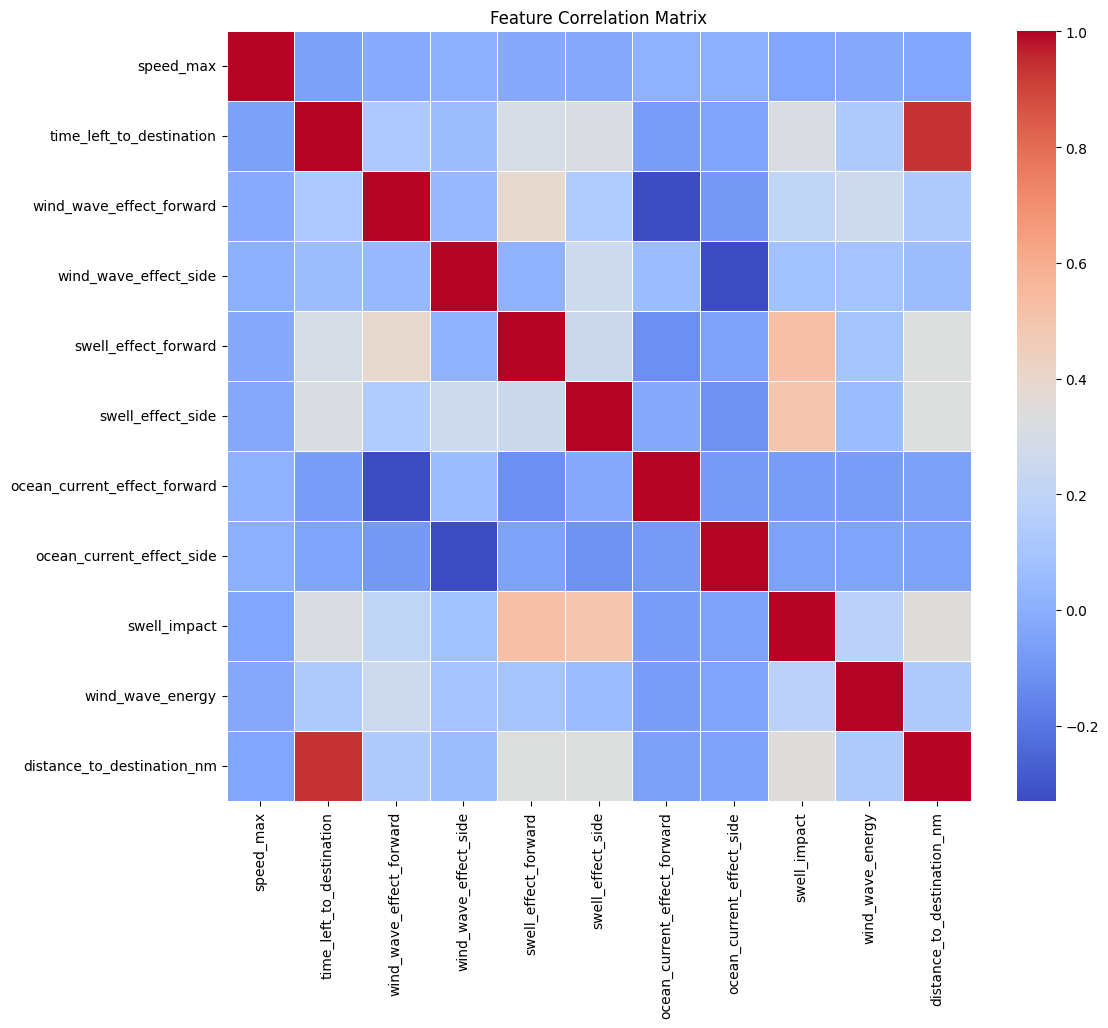

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
correlation_matrix = eta_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()